#Santiago's all nighter
*a.k.a the SMA saver*
*a.k.a the best project in this course*

## **contents**

1. Dependencies and network loading
2. Data management and network exploration
3. Network analysis (and custom algorithm)
4. Network visualization

Special thanks to my adhd, donate beers and CHF please

In [ ]:
!pip install chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 46.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=b48c6bdf177e4c2e9cae059bc0a433e54158fef3054e5d70faebfbe87170c4d8
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


#Enhanced notes for the graph loading so we all get it

Lovely work lads! I love what you did, if I were to put it in words for the report (very technical and fancy) I will do it as follows:


> We first load a curated dataset from chess.com using the chess library to manage the specific chess-related dependencies such as the fed structure. We then performed a topological sort based on the number of visits and created an structure where the edge corresponds to it's hash ID, the edges as the direct link from one chess disposition to another. We also added relevant information over the nodes (fen: i.e., the chessboard pieces distribution; the total number of visits to this node, and the amount of outcomes resulting from this chess position <win, loss, draw>) and edges (probabilty of reaching this node, and overall count of games that have reached this game).

pretty cool huh? without AI baby



In [ ]:
#Graph loading using chess, son and NX
import networkx as nx
import json
import chess

#file_path = 'chess_graph_small.json'

file_path = "chess_graph_2015_05_6k.json"

with open(file_path, 'r') as file:
    raw_data = json.load(file)

# 2. Sort the data by 'total_visits' descending
# This ensures the starting position (most visits) is at index 0
sorted_items = sorted(
    raw_data.items(),
    key=lambda item: item[1].get('total_visits', 0),
    reverse=True
)

# Convert back to an ordered dictionary
ordered_data = dict(sorted_items)

# 3. Construct the Directed Graph
G = nx.DiGraph()

# Add nodes first to preserve the 'topological' visit-based order
for node_hash, node_info in ordered_data.items():
    G.add_node(node_hash,
               fen=node_info.get('fen'),
               visits=node_info.get('total_visits'),
               outcomes=node_info.get('outcomes'))

# Now add the edges
for node_hash, node_info in ordered_data.items():
    edges = node_info.get('edges', {})
    for next_hash, edge_data in edges.items():
        # We only add edges if the destination exists in our node list
        if G.has_node(next_hash):
            G.add_edge(node_hash, next_hash,
                       weight=edge_data['prob'],
                       count=edge_data['count'])

# 4. Verify the "First" Node
first_node_hash = list(ordered_data.keys())[0]
first_node_data = G.nodes[first_node_hash]

print(f"Total Nodes: {G.number_of_nodes()}")
print(f"First Node Hash: {first_node_hash}")
print(f"First Node Visits: {first_node_data['visits']}")
print(f"First Node FEN: {first_node_data['fen']}")

# Display the board of the first node
if first_node_data['fen']:
    print("\n--- Visual Confirmation of First Node ---")
    print(chess.Board(first_node_data['fen']))


#print(data["5060803636482931868"])

Total Nodes: 6196
First Node Hash: 5060803636482931868
First Node Visits: 960084
First Node FEN: rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1

--- Visual Confirmation of First Node ---
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R


In [ ]:
"""
THE STRUCTURE OF A NODE IN OUR GRAPH
Node: "hash": pointer to next Nod
ID: {
  edges: [hash + probability + count]
  outcomes: Win Draw Loss from that position
  total visits: frequency of games where this position was played
  fen: structure of the chess board <positions current player <w,b>, castleing rules - "turn">
}
"""

'\nTHE STRUCTURE OF A NODE IN OUR GRAPH\nNode: "hash": pointer to next Nod\nID: {\n  edges: [hash + probability + count]\n  outcomes: Win Draw Loss from that position\n  total visits: frequency of games where this position was played\n  fen: structure of the chess board <positions current player <w,b>, castleing rules - "turn">\n}\n'

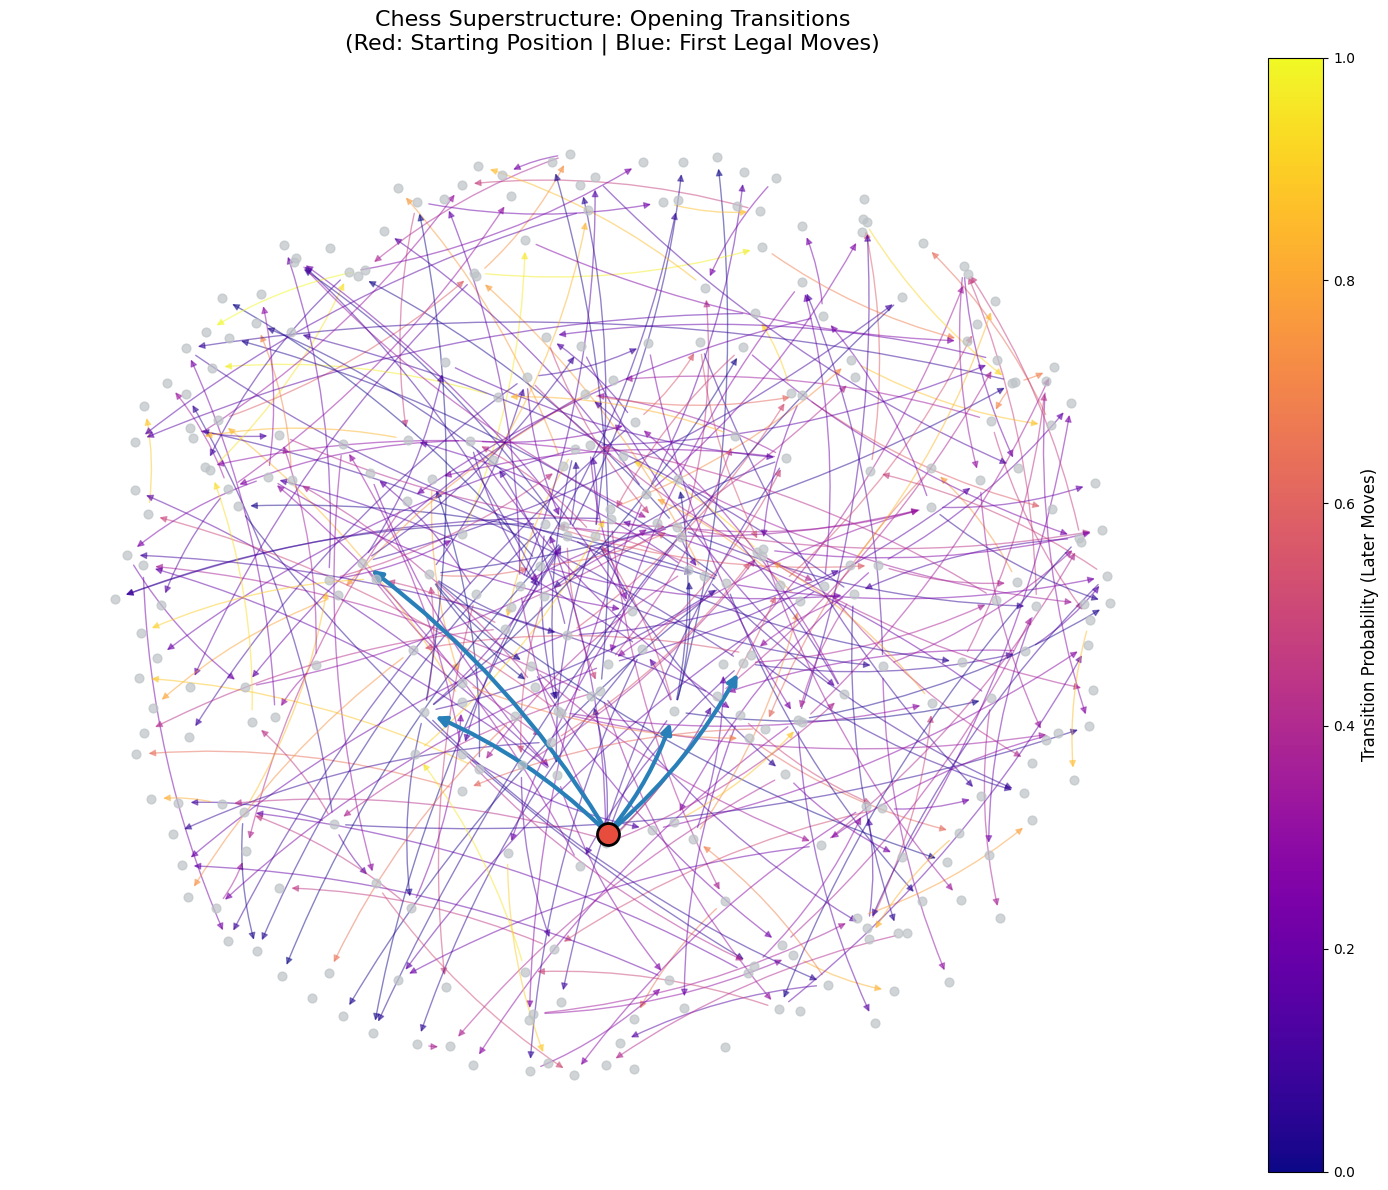

In [ ]:
#Let's look at your cool supergraph guys.
import matplotlib.pyplot as plt
import networkx as nx

# We Filter the graph (Top 300 most visited nodes)
TOP_N = 300
sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get('visits', 0), reverse=True)
core_nodes = [n[0] for n in sorted_nodes[:TOP_N]]
core_G = G.subgraph(core_nodes)

# We know the first node is the one with the most visits. I want to color it in red for explainability
first_node_hash = core_nodes[0]

plt.figure(figsize=(14, 12))

# layout
pos = nx.spring_layout(core_G, k=0.3, iterations=50)

# All the other nodes and edges

# Separate nodes and edges
other_nodes = [node for node in core_G.nodes() if node != first_node_hash]
other_edges = [(u, v) for u, v in core_G.edges() if u != first_node_hash]

# Draw standard nodes
nx.draw_networkx_nodes(core_G, pos,
                       nodelist=other_nodes,
                       node_size=40,
                       node_color='#bdc3c7',
                       alpha=0.7)

# Draw standard edges (probability colormap)
other_edge_probs = [core_G[u][v].get('weight', 0.0) for u, v in other_edges]
nx.draw_networkx_edges(
    core_G, pos,
    edgelist=other_edges,
    edge_color=other_edge_probs,
    edge_cmap=plt.cm.plasma,
    width=1.0,
    alpha=0.5, # Slightly transparent to let the root edges pop
    arrowsize=10,
    connectionstyle="arc3,rad=0.1"
)

# Now I want to draw the first node and it's connections (second moves)

# Draw the starting node (larger, red, with a border)
nx.draw_networkx_nodes(core_G, pos,
                       nodelist=[first_node_hash],
                       node_size=250, # Significantly larger
                       node_color='#e74c3c', # A clean, professional red
                       edgecolors='black',
                       linewidths=2,
                       alpha=1.0)

# Draw direct connections from the start node (thicker, solid blue)
direct_edges = [(u, v) for u, v in core_G.edges() if u == first_node_hash]
nx.draw_networkx_edges(
    core_G, pos,
    edgelist=direct_edges,
    edge_color='#2980b9', # A sharp, structural blue
    width=3.0, # Thicker lines to show primary pathways
    alpha=1.0,
    arrowsize=15,
    connectionstyle="arc3,rad=0.1"
)

# A little makeup so it looks nice
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
cbar.set_label('Transition Probability (Later Moves)', fontsize=12)

plt.title(f'Chess Superstructure: Opening Transitions\n(Red: Starting Position | Blue: First Legal Moves)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Data management polish and network exploration

The algorithm we want to implement without APIs or libraries needs to be a nice regression that uses the best of graph theory (in this case information difussion) to find the coolest paths. (bare with me bro, it's 1 am).

As before, the fancy way I will place this on the report will be:

> In order to implement a graph analysis technique that will provide a meaningful result to our specific field of research we propose to perform an Outcome-weighted path scoring by using a modified Depth-limited depth first search algorithm as it is one of the most significant information difussion techniques.

wombojombo aside, I thought the best way to do a weighted approach is to use DFS with a new metric created based on our data (to also make data enrichment):

$$E[v] = \frac{W_v - L_v}{W_v + L_v + D_v}$$

Nothing to particulary crazy: since we have the counts for each node and remember college-level statistics, we can create the Expected value, as a likelihood value of winning or loosing given all the possible values.

Enriching a DFS with this metric looks cool and it's the best I could think of in a redbull-powered midnight spree.

And in case you missed the day where they taught this in statistics, we make expected values as a function so we can get values from -1 to 1, where 1 is 100% win, -1 is 100% loss, and 0 is a perfect balance.

> Añadir blockquote



Once again, since adhd has kicked in **HAAARDDD**, I will put this into the report like this:

> The usage of a custom expected value function based on the current node counts (i.e., overall count of wining, losing, or drawing based on the current position) was suggested following equation 1, it's purpose is to provide a normalized metric with which to enrich a DFS algorithm based on the combination of the next step node to go from the current position considering both the associated probability and the Expected value of the selecting this node.

May god bless my soul bro.

## Network exploration

You thought I forgot about it didn't you? well I didn't , Pull other metrics from your ass, but I thought about four so far

1. **Network density**: stupid metric to be honest, but it is important to validate that chess is a sparse graph. Density measures how conected is a graph from 0 to 1; if we have a dense graph (several nodes connected or completed) it will reach 1, we obviusly need to check this goes near zero if we're playing smart chess (low density = smart players since their movements are not exactly random)

2. **Page Rank**: Take your notes from SMA fuckers, PageRank is the algorithm Mourad told us from Google to rank the web pages. Why does it matter here? because it measures the "transitive importance" (relevant + connected to other relevant nodes), translated to our game this measures **transpositons** how famous a node is meaning how many paths lead to this node.

3. **Betweeness centrality**: class 1 lads! BC is the metric to measure who are the "bridges" or "bottlenecks" in our graph. In chess this will mean the points of no return.

4. **Out degree centrality**: My final chef-kiss to this BS, we care for the nodes with the most possible moves to go out from, the nodes with the most branches.

Put this nicely on the report lads, **1:30 AM LET'S GOOOO**. I will make a small paragraph that looks like this:

> We used Density to validate the sparse, sequential nature of the game. We used PageRank to find unavoidable transpositional hubs, Betweenness to identify the structural bottlenecks bridging the opening and mid-game, and Out-Degree Centrality to map the nodes with the highest tactical complexity."

Since my autism knows no limits, I created this beautiful graph visualization for the metrics along with the visualization for the Expected value ;)




In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities
import numpy as np

# Calculate and store Expected Value (E[v]) for every node
for node in G.nodes():
    # Outcomes: [Win, Draw, Loss]
    outcomes = G.nodes[node].get('outcomes', [0, 0, 0])
    if outcomes is None: outcomes = [0, 0, 0]

    W, D, L = outcomes[0], outcomes[1], outcomes[2]
    total = W + D + L

    if total > 0:
        G.nodes[node]['expected_value'] = (W - L) / total
    else:
        G.nodes[node]['expected_value'] = 0.0

"""
NETWORK EXPLORATION
"""
# Structural properties
print(f"Network Density: {nx.density(G):.5f}")

# Centrality: PageRank identifies 'hub' chess states that games frequently funnel through
pagerank = nx.pagerank(G, weight='weight')
top_pagerank_node = max(pagerank, key=pagerank.get)
betweenness = nx.betweenness_centrality(core_G)
top_bc = max(betweenness, key=betweenness.get)

print(f"\n--- Network Centrality Metrics ---")
print(f"Node with highest PageRank (Most Central State): {top_pagerank_node}")
print(f"Highest PageRank Score: {pagerank[top_pagerank_node]:.5f}")
print(f"Betweenesss centrality score: {top_bc}")

Network Density: 0.00023

--- Network Centrality Metrics ---
Node with highest PageRank (Most Central State): 4918247330996767761
Highest PageRank Score: 0.00250
Betweenesss centrality score: 8704797333742910878


I added a cool visualization for the Expected value accross nodes and the pageRank score

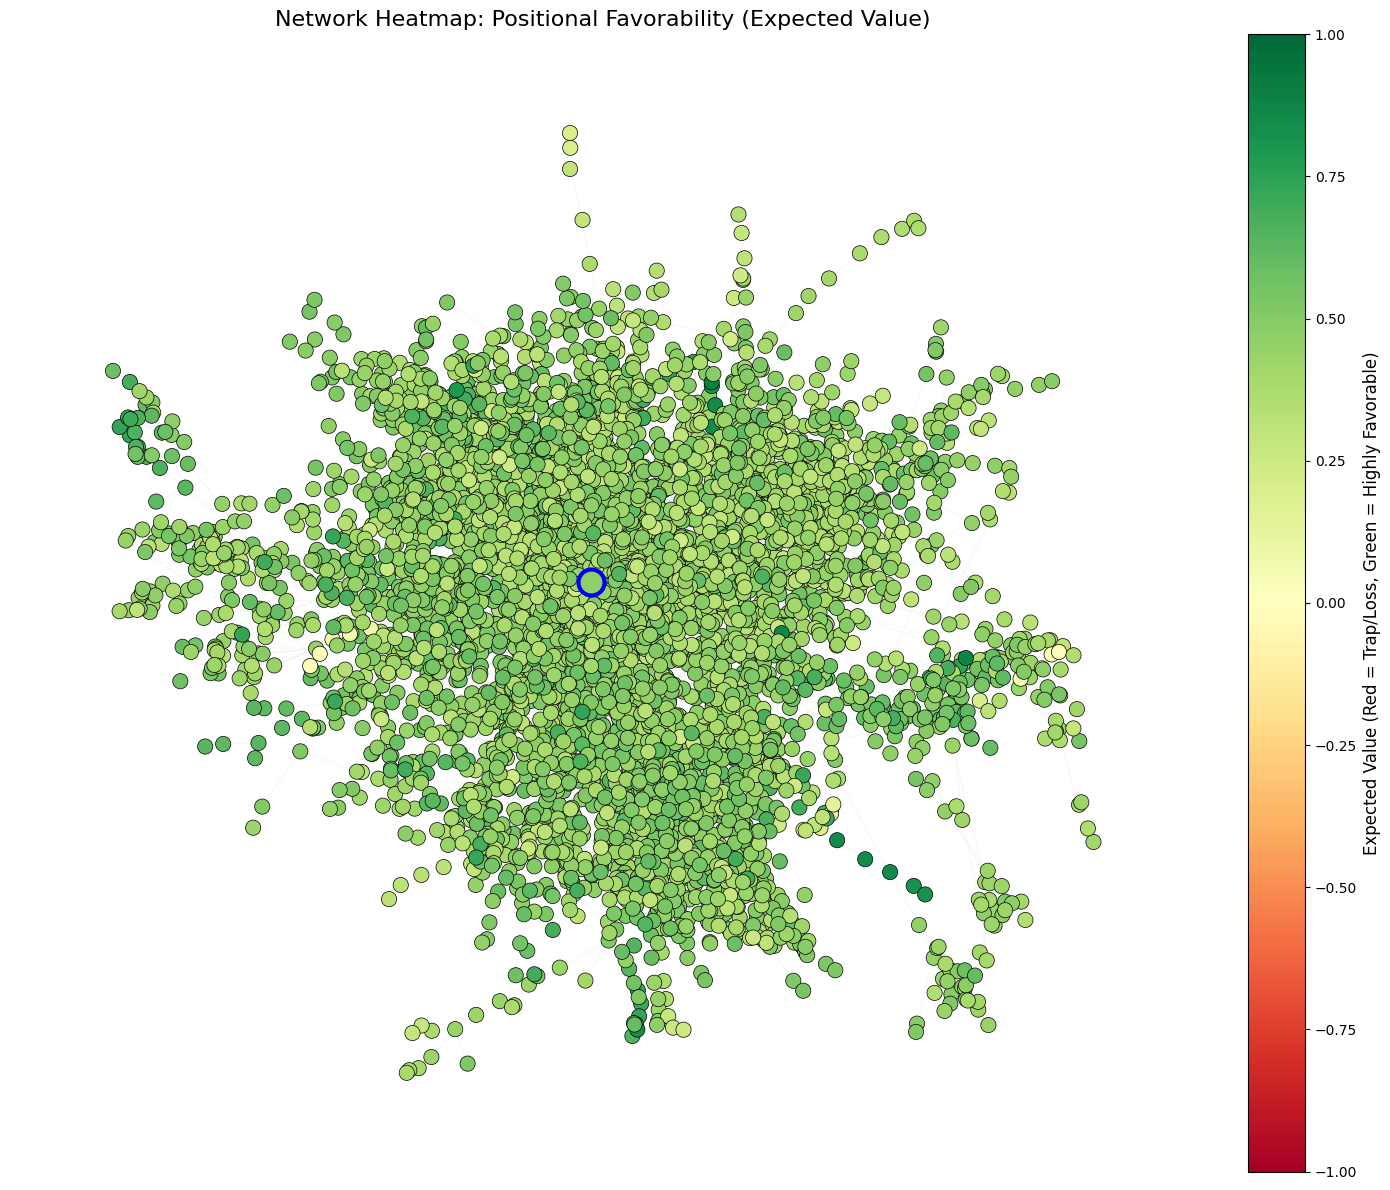

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# expected value heatmap
# 1. Extract the Core Network
TOP_N = 6000
sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get('visits', 0), reverse=True)
core_nodes = [n[0] for n in sorted_nodes[:TOP_N]]
core_G = G.subgraph(core_nodes)

pos = nx.spring_layout(core_G, k=0.3, iterations=50)

# 3. Extract EVs for color mapping
node_evs = [core_G.nodes[n].get('expected_value', 0.0) for n in core_G.nodes()]

plt.figure(figsize=(14, 12))

nx.draw_networkx_edges(core_G, pos,
                       edge_color='#ecf0f1',
                       alpha=0.4,
                       width=1.0,
                       arrows=False)

nodes_plot = nx.draw_networkx_nodes(
    core_G, pos,
    node_size=120,
    node_color=node_evs,
    cmap=plt.cm.RdYlGn, # Red (Loss) -> Yellow (Draw/Eq) -> Green (Win)
    vmin=-1.0, # Minimum possible EV
    vmax=1.0,  # Maximum possible EV
    edgecolors='black',
    linewidths=0.5
)

# 6. Highlight the Starting Node (Thick blue border)
first_node_hash = core_nodes[0]
nx.draw_networkx_nodes(
    core_G, pos,
    nodelist=[first_node_hash],
    node_size=350,
    node_color=[core_G.nodes[first_node_hash].get('expected_value', 0.0)],
    cmap=plt.cm.RdYlGn,
    vmin=-1.0,
    vmax=1.0,
    edgecolors='#0000ff', # Blue highlight for the root
    linewidths=3
)

# 7. Add Colorbar & Polish
cbar = plt.colorbar(nodes_plot, ax=plt.gca(), fraction=0.046, pad=0.04)
cbar.set_label('Expected Value (Red = Trap/Loss, Green = Highly Favorable)', fontsize=12)

plt.title('Network Heatmap: Positional Favorability (Expected Value)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

Calculating Centrality Metrics...


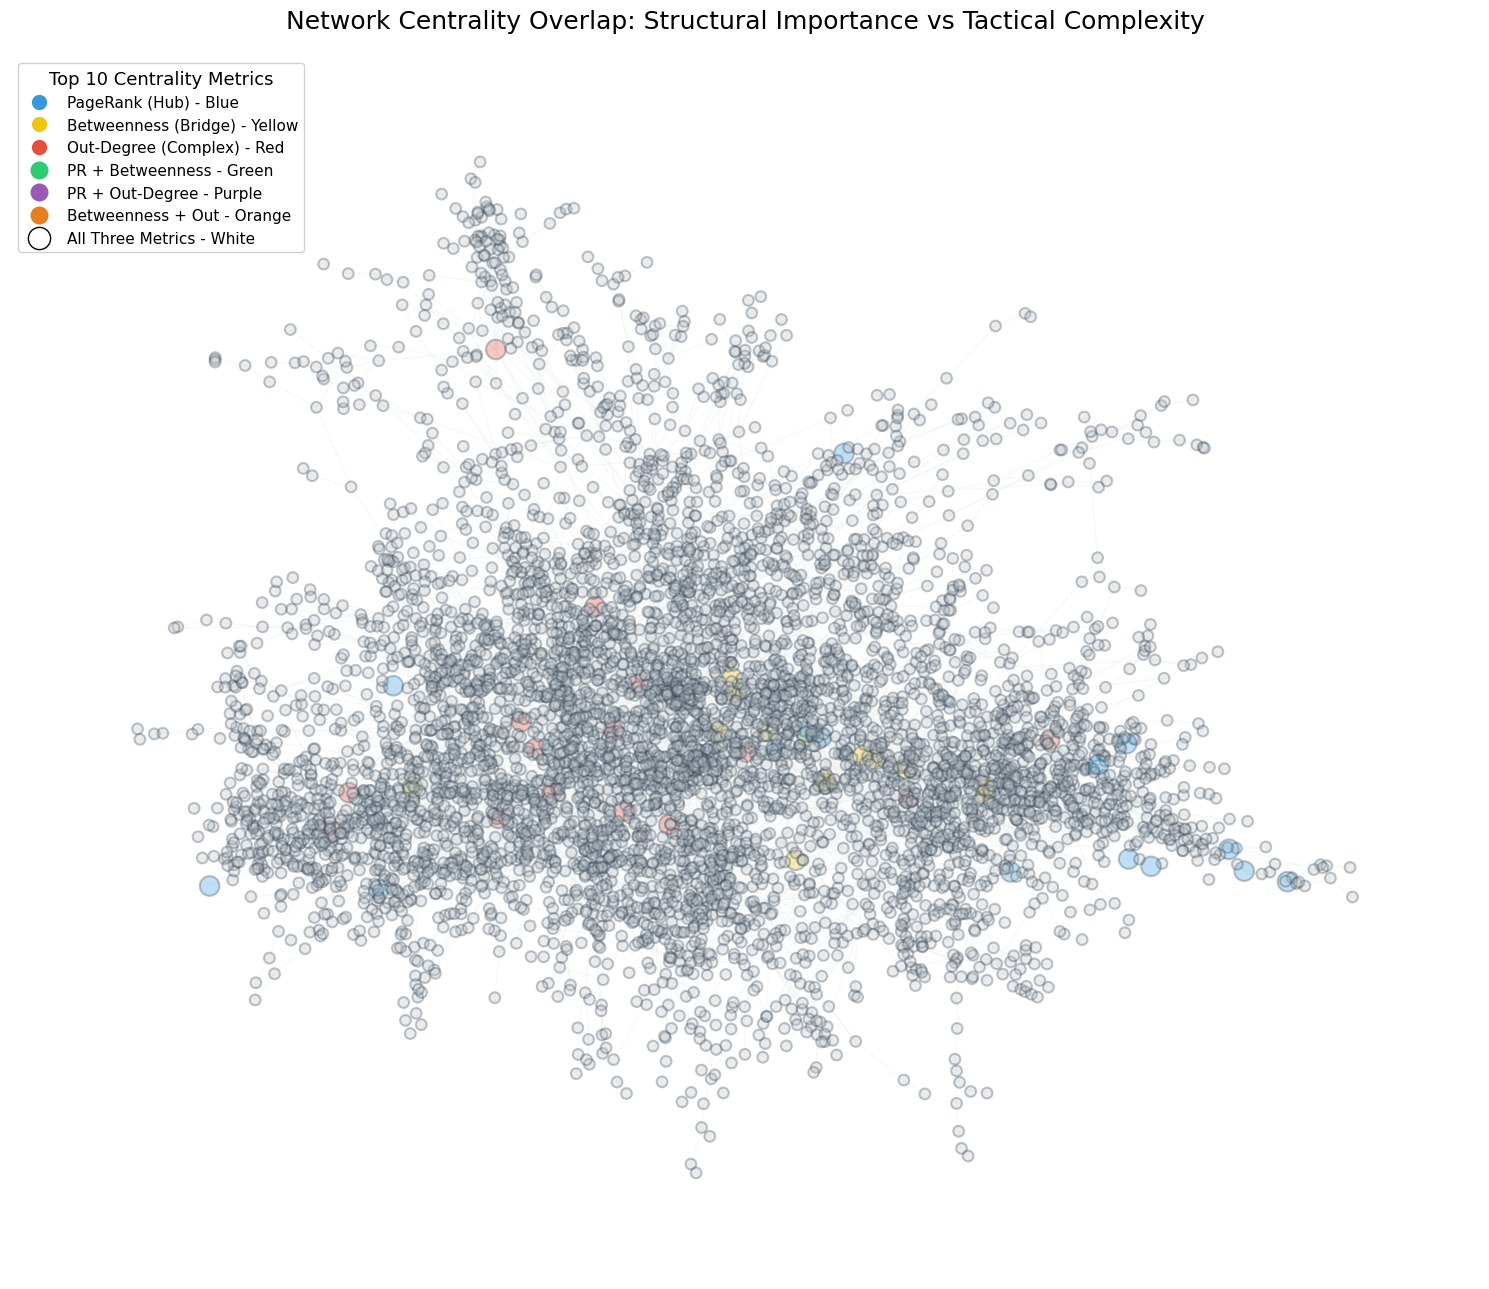

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

# Centrality overlap visualization
# 1. Filter Graph
TOP_N = 6000
amount_2_draw = 15
sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get('visits', 0), reverse=True)
core_nodes = [n[0] for n in sorted_nodes[:TOP_N]]
core_G = G.subgraph(core_nodes)

# 2. Compute the Metrics strictly on our visual Core Graph
print("Calculating Centrality Metrics...")

# PageRank (Blue)
pagerank = nx.pagerank(core_G, weight='weight')
top_pr = set(sorted(pagerank, key=pagerank.get, reverse=True)[:amount_2_draw])

# Betweenness (Yellow)
betweenness = nx.betweenness_centrality(core_G)
top_bet = set(sorted(betweenness, key=betweenness.get, reverse=True)[:amount_2_draw])

# Out-Degree (Red)
out_degree = dict(core_G.out_degree())
top_out = set(sorted(out_degree, key=out_degree.get, reverse=True)[:amount_2_draw])

# 3. Apply the Color Mixing Logic
node_colors = []
node_sizes = []

for node in core_G.nodes():
    in_pr = node in top_pr
    in_bet = node in top_bet
    in_out = node in top_out

    # Check overlaps first (The Venn Diagram logic)
    if in_pr and in_bet and in_out:
        color = '#ffffff' # White (All three)
        size = 500
    elif in_pr and in_bet:
        color = '#2ecc71' # Green (Blue + Yellow)
        size = 350
    elif in_pr and in_out:
        color = '#9b59b6' # Purple (Blue + Red)
        size = 350
    elif in_bet and in_out:
        color = '#e67e22' # Orange (Yellow + Red)
        size = 350
    elif in_pr:
        color = '#3498db' # Blue
        size = 200
    elif in_bet:
        color = '#f1c40f' # Yellow
        size = 200
    elif in_out:
        color = '#e74c3c' # Red
        size = 200
    else:
        color = '#bdc3c7' # Light Gray
        size = 60

    node_colors.append(color)
    node_sizes.append(size)

plt.figure(figsize=(15, 13))
pos = nx.spring_layout(core_G, k=0.35, iterations=50)

nx.draw_networkx_edges(core_G, pos, edge_color='#ecf0f1', alpha=0.4, width=1.0, arrows=False)

nx.draw_networkx_nodes(core_G, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       edgecolors='#2c3e50', # Dark border to make white/yellow pop
                       linewidths=1.5, alpha=0.3)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='PageRank (Hub) - Blue', markerfacecolor='#3498db', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Betweenness (Bridge) - Yellow', markerfacecolor='#f1c40f', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Out-Degree (Complex) - Red', markerfacecolor='#e74c3c', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='PR + Betweenness - Green', markerfacecolor='#2ecc71', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='PR + Out-Degree - Purple', markerfacecolor='#9b59b6', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='Betweenness + Out - Orange', markerfacecolor='#e67e22', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='All Three Metrics - White', markerfacecolor='#ffffff', markeredgecolor='black', markersize=16),
]

plt.legend(handles=legend_elements, loc='upper left', title="Top 10 Centrality Metrics",
           fontsize=11, title_fontsize=13, framealpha=0.9)

plt.title('Network Centrality Overlap: Structural Importance vs Tactical Complexity', fontsize=18, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Task for the almighty Bela

It would be really cool to actually open those nodes and check how they look from a seasoned player perspective. This will lead to a super cool analysis. Let me know if you need help.

# Network analysis

In order to make some nice analysis I'm proposing two different techniques: clusterization and our modified DFS. Since a very important part of our grade is the implementation of the DFS on our own I will describe it with excruciating detail.

## Cluster finding (community detection)

Greedy modularity is the way to go with this, the reasoning behind it? it is perfect to find clusters of "game states"

## Modified Depth-limited depth first search

The custom algorithm explained in pseudo-code can be told as a recursive algorithm that follows:

1. Select a node v
2. if the current depth is the limit of our search, or there is no more paths to explore, we finish the search.
3. (recursive) if v has out-degree (successors), for each node u:
  - extract the child probabilty and expected value
  - calculate the probality * expected value
  - perform next step





In [ ]:
"""
Network analysis
"""
# Community Detection (Using built-in library)
# Convert to undirected temporarily for community detection
undirected_G = G.to_undirected()
# Using greedy modularity to find clusters of game states
communities = list(greedy_modularity_communities(undirected_G))
print(f"\nDetected {len(communities)} distinct communities (clusters of game states).")


# Custom Algorithm: Outcome-Weighted Path Scoring (From Scratch)
def get_top_weighted_paths(graph, start_node, depth_limit=4, top_k=5):
    """
    Custom Depth-Limited DFS to find the highest-scoring tactical paths.
    Does not use external pathfinding libraries.
    """
    valid_paths = []

    def custom_dfs(current_node, current_path, current_score, current_depth):
        # Base case: reached depth limit or a leaf node (checkmate/draw/end of data)
        if current_depth == depth_limit or graph.out_degree(current_node) == 0:
            valid_paths.append((current_path, current_score))
            return

        # Recursive case: explore successors
        for next_node in graph.successors(current_node):
            edge_prob = graph[current_node][next_node].get('weight', 0.0) #current edge probability
            child_ev = graph.nodes[next_node].get('expected_value', 0.0) #success of move given the future step/child

            # Heuristic calculation: Edge Probability * Expected Value of the outcome
            step_score = edge_prob * child_ev

            # Continue search deeper
            custom_dfs(next_node,
                       current_path + [next_node],
                       current_score + step_score,
                       current_depth + 1)

    # Initialize DFS from the starting node
    custom_dfs(start_node, [start_node], 0.0, 0)

    # Sort paths by score descending (from scratch sorting logic via lambda)
    valid_paths.sort(key=lambda x: x[1], reverse=True)

    return valid_paths[:top_k]

print("\n--- Running Custom Path Scoring Algorithm ---")
top_paths = get_top_weighted_paths(G, first_node_hash, depth_limit=4, top_k=3)

for i, (path, score) in enumerate(top_paths):
    print(f"Rank {i+1} Path Score: {score:.4f}")
    print(f"Path Nodes: {path}\n")


Detected 143 distinct communities (clusters of game states).

--- Running Custom Path Scoring Algorithm ---
Rank 1 Path Score: 1.1090
Path Nodes: ['5060803636482931868', '9384546495678726550', '595762792459712928', '15213300192948443293', '8704797333742910878']

Rank 2 Path Score: 1.0795
Path Nodes: ['5060803636482931868', '9384546495678726550', '528813709611831216', '2344601935407631798', '11863996697488666748']

Rank 3 Path Score: 0.9449
Path Nodes: ['5060803636482931868', '9384546495678726550', '595762792459712928', '15213300192948443293', '16905080946651992560']



# Network visualization

2 am and I'm one hell of an ambitious moron, after running a simple greedy algorithm for the comunities (nothing to special) I also wanted to draw the top 5 paths identified by our machine.  The beauty of making a spectrum in size and color is to show that the paths are actually starting in similar nodes to the diverge! which combines what we saw on the previous visualizations as these "divergent" nodes (Bela's homework).

While being an absolute bimbo who doesn't know sht about chess, my conclusion based on our algorithm is rather simple: follow the paths and know that your goal is to send your oponent into a position that throws him into an unexpected path.

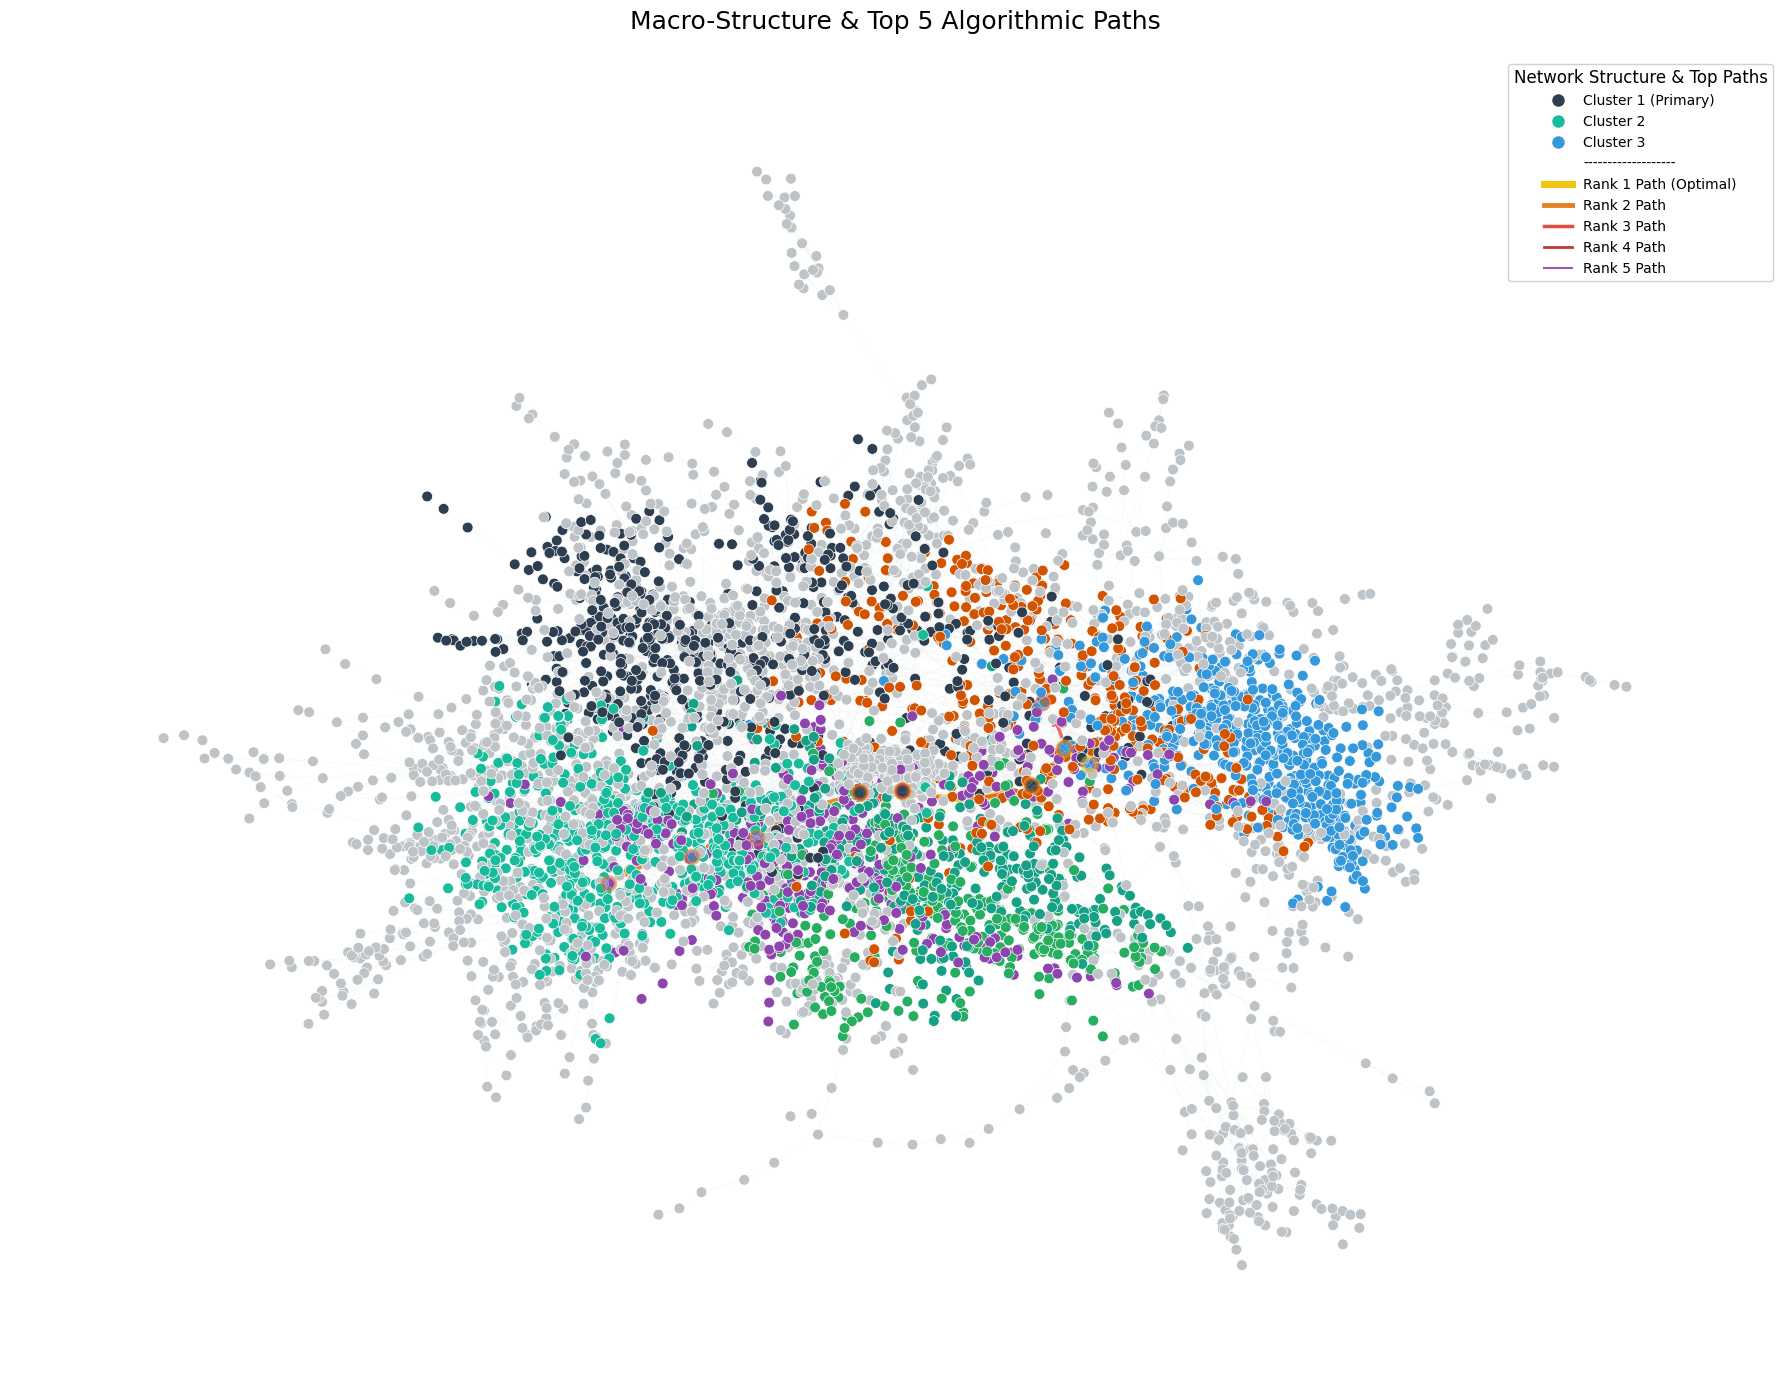

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
from matplotlib.lines import Line2D

TOP_N = 6000
sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get('visits', 0), reverse=True)
core_nodes = [n[0] for n in sorted_nodes[:TOP_N]]
core_G = G.subgraph(core_nodes)

# 2. Community Detection
undirected_core = core_G.to_undirected()
communities = list(greedy_modularity_communities(undirected_core))

community_colors = ['#2c3e50', '#18bc9c', '#3498db', '#8e44ad', '#d35400', '#16a085', '#27ae60']
node_color_map = {}

for i, comm in enumerate(communities):
    color = community_colors[i] if i < len(community_colors) else '#bdc3c7'
    for node in comm:
        if node in core_G:
            node_color_map[node] = color

node_colors = [node_color_map.get(n, '#bdc3c7') for n in core_G.nodes()]
node_sizes = [200 if n == first_node_hash else 60 for n in core_G.nodes()]

plt.figure(figsize=(18, 14)) # Slightly larger canvas
pos = nx.spring_layout(core_G, k=0.15, iterations=60, seed=42) # k=0.25 spreads the expanded clusters out nicely

# Draw standard edges and nodes
nx.draw_networkx_edges(core_G, pos, edge_color='#ecf0f1', alpha=0.3, width=0.8, arrows=False)
nx.draw_networkx_nodes(core_G, pos, node_size=node_sizes, node_color=node_colors, edgecolors='#ffffff', linewidths=0.5)

# We create a gradient style for the paths: Gold (Rank 1) -> Purple (Rank 5)
path_colors = ['#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#9b59b6']
path_widths = [5.0, 3.5, 2.5, 2.0, 1.5]
path_alphas = [1.0, 0.9, 0.8, 0.7, 0.6]

for rank in range(min(5, len(top_paths))):
    path_nodes = top_paths[rank][0]
    path_edges = [(path_nodes[i], path_nodes[i+1]) for i in range(len(path_nodes)-1)]

    drawable_edges = [(u, v) for u, v in path_edges if u in core_G and v in core_G]
    drawable_nodes = [n for n in path_nodes if n in core_G]

    # Highlight Path Nodes
    nx.draw_networkx_nodes(core_G, pos, nodelist=drawable_nodes, node_size=100,
                           node_color=[node_color_map.get(n) for n in drawable_nodes],
                           edgecolors=path_colors[rank], linewidths=path_widths[rank]/1.5, alpha=0.5)

    # Highlight Path Edges
    nx.draw_networkx_edges(core_G, pos, edgelist=drawable_edges, edge_color=path_colors[rank],
                           width=path_widths[rank], alpha=path_alphas[rank],
                           arrowsize=15, connectionstyle="arc3,rad=0.15")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Cluster 1 (Primary)', markerfacecolor=community_colors[0], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster 2', markerfacecolor=community_colors[1], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Cluster 3', markerfacecolor=community_colors[2], markersize=10),
    Line2D([0], [0], color='w', label='-------------------'),
    Line2D([0], [0], color=path_colors[0], lw=5, label='Rank 1 Path (Optimal)'),
    Line2D([0], [0], color=path_colors[1], lw=3.5, label='Rank 2 Path'),
    Line2D([0], [0], color=path_colors[2], lw=2.5, label='Rank 3 Path'),
    Line2D([0], [0], color=path_colors[3], lw=2, label='Rank 4 Path'),
    Line2D([0], [0], color=path_colors[4], lw=1.5, label='Rank 5 Path'),
]

plt.legend(handles=legend_elements, loc='upper right', title="Network Structure & Top Paths",
           fontsize=10, title_fontsize=12, framealpha=0.9)

plt.title('Macro-Structure & Top 5 Algorithmic Paths', fontsize=18, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Final surprise: Regression
*Because sleeping is for suckers and I still have taurin in my body*

Our DFS is cool and everything, but you can't really use it in a real game since it is too computationally heavy (all the tests I did tonight are only with 300 nodes (It will be your computer's task to get toasted to check how this looks with all nodes involved)

To use ML to find the best outcomes is exactly the regression Bela suggested as a lovely outcome. So I build a not-so-fancy approach to it: A vanilla random forest.



In [ ]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Feature Extraction Function
def extract_path_features(graph, path):
    """Converts a path into a ML vector."""
    edge_probs = []
    node_evs = []
    out_degrees = []

    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        edge_probs.append(graph[u][v].get('weight', 0.0))
        node_evs.append(graph.nodes[v].get('expected_value', 0.0))
        out_degrees.append(graph.out_degree(v))

    return {
        'path_length': len(path),
        'avg_edge_prob': np.mean(edge_probs) if edge_probs else 0,
        'min_edge_prob': np.min(edge_probs) if edge_probs else 0, # Bottlenecks or bridges
        'avg_expected_value': np.mean(node_evs) if node_evs else 0,
        'terminal_node_ev': node_evs[-1] if node_evs else 0,
        'avg_out_degree': np.mean(out_degrees) if out_degrees else 0
    }

# 2. Generate a Training Dataset via Random Walks
training_data = []

# 1000 random walks starting from highly visited nodes
walk_starts = [n for n, d in sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:50]]

for start_node in walk_starts:
    for _ in range(20): # 20 walks per start node
        current_node = start_node
        path = [current_node]
        path_score = 0.0

        for _ in range(5):
            successors = list(G.successors(current_node))
            if not successors:
                break

            next_node = random.choice(successors)

            # score (Our Target Variable 'y')
            step_prob = G[current_node][next_node].get('weight', 0.0)
            step_ev = G.nodes[next_node].get('expected_value', 0.0)
            path_score += (step_prob * step_ev)

            path.append(next_node)
            current_node = next_node

        if len(path) > 2: # Only keep meaningful paths
            features = extract_path_features(G, path)
            features['target_score'] = path_score
            training_data.append(features)

df = pd.DataFrame(training_data)

# 3. Train the Regression Model
print(f"Training Random Forest on {len(df)} paths...")
X = df.drop(columns=['target_score'])
y = df['target_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nModel Performance:")
print(f"R-squared Score: {r2:.4f} (How well topology predicts outcome)")
print(f"Root Mean Squared Error: {rmse:.4f}")

# Feature Importance
importances = model.feature_importances_
feature_names = X.columns
print("\nMost Critical Structural Features for Winning:")
for name, importance in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"- {name}: {importance:.3f}")

# Top 5 Algorithm Paths!
print("\nTesting ML Model against our Top 5 DFS Paths:")
for i, (path, actual_score) in enumerate(top_paths):
    path_features = pd.DataFrame([extract_path_features(G, path)])
    predicted_score = model.predict(path_features)[0]
    print(f"Rank {i+1} Path | Math Score: {actual_score:.4f} | ML Predicted Score: {predicted_score:.4f}")

Training Random Forest on 946 paths...

Model Performance:
R-squared Score: 0.9911 (How well topology predicts outcome)
Root Mean Squared Error: 0.0305

Most Critical Structural Features for Winning:
- avg_edge_prob: 0.663
- path_length: 0.247
- avg_expected_value: 0.059
- terminal_node_ev: 0.022
- min_edge_prob: 0.007
- avg_out_degree: 0.003

Testing ML Model against our Top 5 DFS Paths:
Rank 1 Path | Math Score: 1.1090 | ML Predicted Score: 1.0968
Rank 2 Path | Math Score: 1.0795 | ML Predicted Score: 1.1279
Rank 3 Path | Math Score: 0.9449 | ML Predicted Score: 1.0182


# The end of the night: 2:10

FInished in record time lads! let me tell you a little about the ML model, why the hell it matters and some nice graphics for the slides.

## Why an RF?

Simple: we need a regression of the best paths, by building a vector that contains all the important values of the graph (path lenght, average dege probabilty, minimum edge probabilty, average expected value, terminal nove EV, and average out degree) to predict the best score (our heuristic) we can quickly sample paths and find if the outcome is better compared to other paths, meaning that we can map an strategy based on human decision and measure how good it is compared to this dataset!

I added the traditional regression score so you can check how cool it is

Good night boys :D

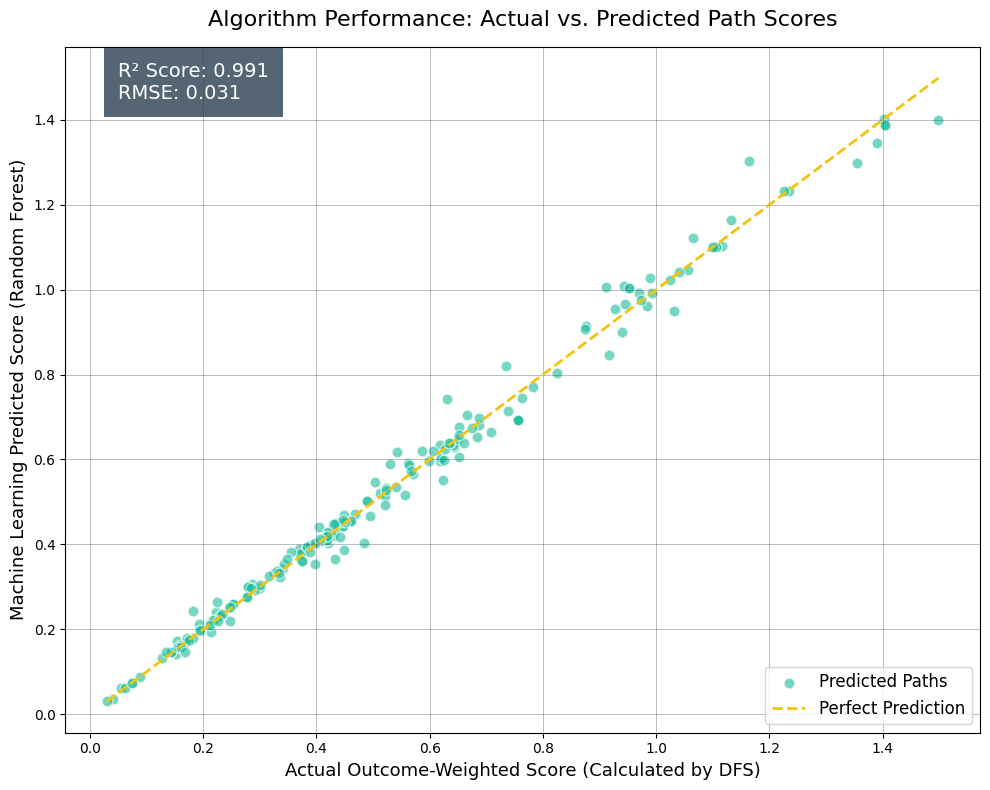

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Scatter plot of True vs Predicted scores
plt.scatter(y_test, y_pred, color='#18bc9c', alpha=0.6, edgecolor='white', s=60, label='Predicted Paths')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#f1c40f', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Algorithm Performance: Actual vs. Predicted Path Scores', fontsize=16, pad=15)
plt.xlabel('Actual Outcome-Weighted Score (Calculated by DFS)', fontsize=13)
plt.ylabel('Machine Learning Predicted Score (Random Forest)', fontsize=13)

plt.text(min_val + 0.02, max_val - 0.05, f'R² Score: {r2:.3f}\nRMSE: {rmse:.3f}',
         fontsize=14, color='white', bbox=dict(facecolor='#2c3e50', alpha=0.8, edgecolor='none', pad=10))

plt.legend(loc='lower right', fontsize=12)
plt.grid(color='#34495e', linestyle='-', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

plt.style.use('default')

# Ablation studies

We will compare our DFS , networkX DFS, networkX BFS, and networkX Djistra over different subsets of the dataset. We then measure the mathematical score of the best algorithms and measure time towards reaching similar results.

Benchmarking


100%|██████████| 8/8 [00:00<00:00, 25.74it/s]


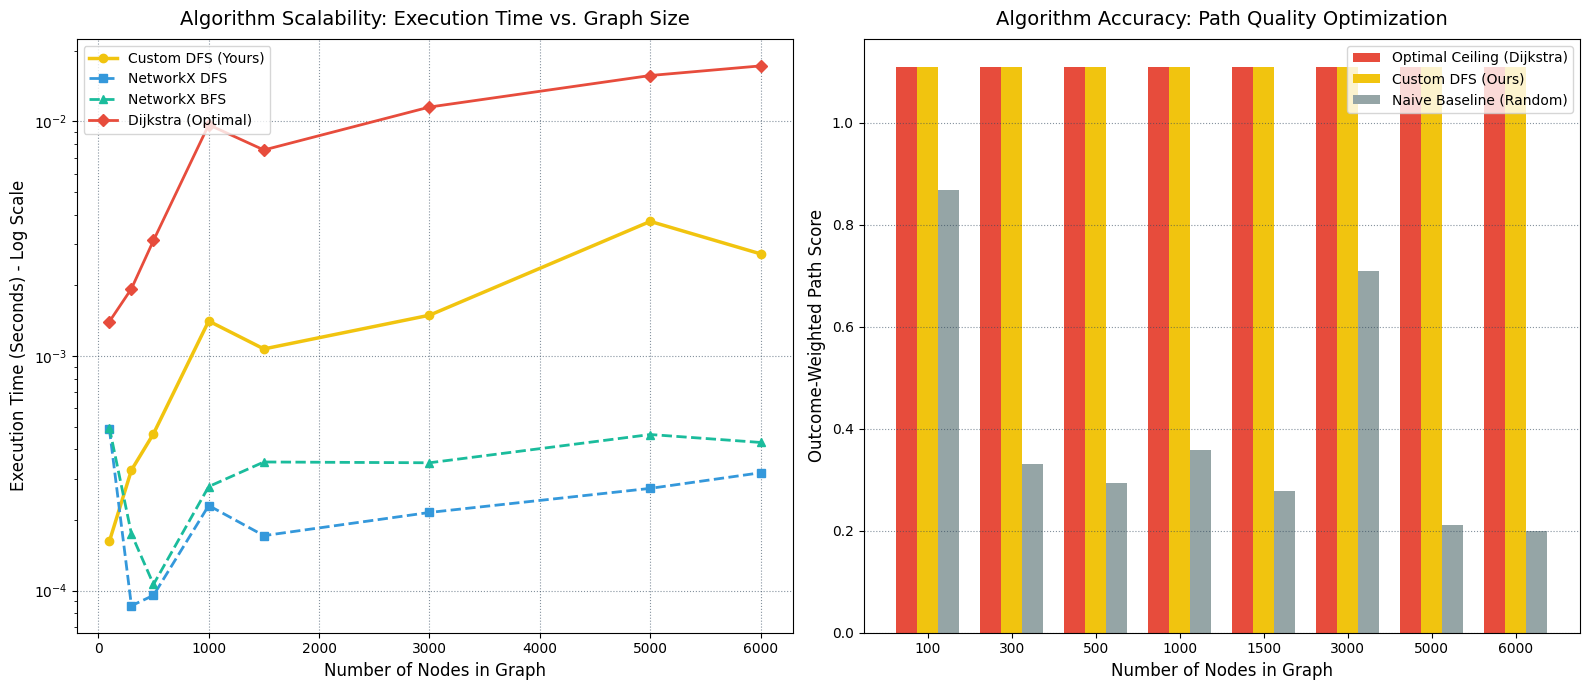

In [ ]:
import time
import random
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
print("Benchmarking")

NODE_SIZES = [100, 300, 500, 1000,1500,3000, 5000,6000]
results = []

# Ensure Djistra inversion of the metric (cost becomes max value)
for u, v, data in G.edges(data=True):
    prob = data.get('weight', 0.0)
    ev = G.nodes[v].get('expected_value', 0.0)
    # We add 1e-6 to avoid zero division, and max to avoid negative costs
    G[u][v]['cost'] = 1.0 / max(prob * ev + 1e-6, 1e-6)

# The Benchmarking Loop
for size in tqdm(NODE_SIZES):

    # Extract Subgraph
    sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get('visits', 0), reverse=True)
    subgraph_nodes = [n[0] for n in sorted_nodes[:size]]
    subG = G.subgraph(subgraph_nodes).copy()
    start_node = subgraph_nodes[0]

    # 1. Custom DFS (Ours)
    start_time = time.perf_counter()
    # (Assuming your get_top_weighted_paths function is loaded in the script)
    custom_paths = get_top_weighted_paths(subG, start_node, depth_limit=4, top_k=1)
    time_custom = time.perf_counter() - start_time
    score_custom = custom_paths[0][1] if custom_paths else 0

    # 2. NetworkX DFS (Blind Traversal)
    start_time = time.perf_counter()
    list(nx.dfs_edges(subG, source=start_node, depth_limit=4))
    time_nx_dfs = time.perf_counter() - start_time

    # 3. NetworkX BFS (Blind Traversal)
    start_time = time.perf_counter()
    list(nx.bfs_edges(subG, source=start_node, depth_limit=4))
    time_nx_bfs = time.perf_counter() - start_time

    # 4. Dijkstra's Algorithm (Optimal Score)
    start_time = time.perf_counter()
    try:
        #find all nodes that are exactly 'depth_limit' away (e.g., 4 moves)
        depth_map = nx.single_source_shortest_path_length(subG, start_node, cutoff=4)
        max_depth = max(depth_map.values()) if depth_map else 0
        target_nodes = [n for n, depth in depth_map.items() if depth == max_depth and n != start_node]

        optimal_path = []
        if target_nodes:
            lowest_cost = float('inf')

            # Ask Dijkstra for the lowest cost path to ANY of those boundary nodes
            for target in target_nodes:
                try:
                    path = nx.shortest_path(subG, start_node, target, weight='cost')
                    # Calculate total path cost
                    cost = sum(subG[path[i]][path[i+1]]['cost'] for i in range(len(path)-1))
                    if cost < lowest_cost:
                        lowest_cost = cost
                        optimal_path = path
                except nx.NetworkXNoPath:
                    continue
        else:
            optimal_path = [start_node]

        time_dijkstra = time.perf_counter() - start_time

        # Calculate our custom score for Dijkstra's chosen path
        score_dijkstra = 0
        if len(optimal_path) > 1:
            for i in range(len(optimal_path)-1):
                u, v = optimal_path[i], optimal_path[i+1]
                score_dijkstra += subG[u][v].get('weight', 0.0) * subG.nodes[v].get('expected_value', 0.0)

    except Exception as e:
        print(f"Dijkstra Error: {e}")
        time_dijkstra = 0
        score_dijkstra = 0

    # 5. Random Walk to compare for random path selections
    score_random = 0
    curr = start_node
    for _ in range(4):
        successors = list(subG.successors(curr))
        if not successors: break
        nxt = random.choice(successors)
        score_random += subG[curr][nxt].get('weight', 0.0) * subG.nodes[nxt].get('expected_value', 0.0)
        curr = nxt

    # Log results
    results.append({
        'Nodes': size,
        'Time_Custom_DFS': time_custom,
        'Time_NX_DFS': time_nx_dfs,
        'Time_NX_BFS': time_nx_bfs,
        'Time_Dijkstra': time_dijkstra,
        'Score_Custom': score_custom,
        'Score_Optimal': score_dijkstra,
        'Score_Random': score_random
    })

df_bench = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Execution Time (Log Scale)
ax1.plot(df_bench['Nodes'], df_bench['Time_Custom_DFS'], marker='o', color='#f1c40f', linewidth=2.5, label='Custom DFS (Yours)')
ax1.plot(df_bench['Nodes'], df_bench['Time_NX_DFS'], marker='s', color='#3498db', linewidth=2, linestyle='--', label='NetworkX DFS')
ax1.plot(df_bench['Nodes'], df_bench['Time_NX_BFS'], marker='^', color='#1abc9c', linewidth=2, linestyle='--', label='NetworkX BFS')
ax1.plot(df_bench['Nodes'], df_bench['Time_Dijkstra'], marker='D', color='#e74c3c', linewidth=2, label='Dijkstra (Optimal)')

ax1.set_yscale('log') # Log scale because time grows exponentially
ax1.set_title('Algorithm Scalability: Execution Time vs. Graph Size', fontsize=14, pad=10)
ax1.set_xlabel('Number of Nodes in Graph', fontsize=12)
ax1.set_ylabel('Execution Time (Seconds) - Log Scale', fontsize=12)
ax1.grid(color='#34495e', linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', fontsize=10)

# Plot 2: Path Quality (Accuracy)
bar_width = 0.25
x = np.arange(len(df_bench['Nodes']))

ax2.bar(x - bar_width, df_bench['Score_Optimal'], width=bar_width, color='#e74c3c', label='Optimal Ceiling (Dijkstra)')
ax2.bar(x, df_bench['Score_Custom'], width=bar_width, color='#f1c40f', label='Custom DFS (Ours)')
ax2.bar(x + bar_width, df_bench['Score_Random'], width=bar_width, color='#95a5a6', label='Naive Baseline (Random)')

ax2.set_title('Algorithm Accuracy: Path Quality Optimization', fontsize=14, pad=10)
ax2.set_xlabel('Number of Nodes in Graph', fontsize=12)
ax2.set_ylabel('Outcome-Weighted Path Score', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(df_bench['Nodes'])
ax2.grid(axis='y', color='#34495e', linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()
plt.style.use('default')

In [ ]:
def get_top_weighted_paths(graph, start_node, depth_limit=4, top_k=5, beam_width=2):
    """
    Custom Heuristic Search (Beam Search).
    beam_width restricts the algorithm to only explore the 'N' best immediate moves,
    sacrificing guaranteed optimality for massive computational speed.
    """
    valid_paths = []

    def custom_dfs(current_node, current_path, current_score, current_depth):
        if current_depth == depth_limit or graph.out_degree(current_node) == 0:
            valid_paths.append((current_path, current_score))
            return

        # 1. Gather all possible next moves and their immediate step scores
        candidates = []
        for next_node in graph.successors(current_node):
            edge_prob = graph[current_node][next_node].get('weight', 0.0)
            child_ev = graph.nodes[next_node].get('expected_value', 0.0)
            step_score = edge_prob * child_ev
            candidates.append((next_node, step_score))

        # 2. THE PRUNING ASSUMPTION: Sort candidates and only keep the top 'beam_width'
        # This is where we stop being exhaustive and start being a fast heuristic!
        candidates.sort(key=lambda x: x[1], reverse=True)
        top_candidates = candidates[:beam_width]

        # 3. Continue search only on the pruned branches
        for next_node, step_score in top_candidates:
            custom_dfs(next_node,
                       current_path + [next_node],
                       current_score + step_score,
                       current_depth + 1)

    custom_dfs(start_node, [start_node], 0.0, 0)
    valid_paths.sort(key=lambda x: x[1], reverse=True)

    return valid_paths[:top_k]

# Non-white biased version

Boy that sounds harsh

In [ ]:
def get_top_weighted_paths(graph, start_node, depth_limit=4, top_k=5, beam_width=2, perspective='optimal'):
    """
    Adversarial Heuristic Search with Perspective Filtering.
    perspective: 'optimal' (best overall game), 'white' (best for white), 'black' (best for black)
    """
    valid_paths = []

    def custom_dfs(current_node, current_path, current_score, current_depth):
        if current_depth == depth_limit or graph.out_degree(current_node) == 0:
            valid_paths.append((current_path, current_score))
            return

        # Determine whose turn it is
        current_fen = graph.nodes[current_node].get('fen', '')
        active_player = current_fen.split(' ')[1] if current_fen else 'w'

        # White wants positive EV (+1), Black wants negative EV (-1)
        player_multiplier = 1 if active_player == 'w' else -1

        candidates = []
        for next_node in graph.successors(current_node):
            edge_prob = graph[current_node][next_node].get('weight', 0.0)
            child_ev = graph.nodes[next_node].get('expected_value', 0.0)

            # Step score is evaluated from the active player's perspective
            step_score = edge_prob * (child_ev * player_multiplier)
            candidates.append((next_node, step_score))

        # Prune branches (Keep the best moves for the active player)
        candidates.sort(key=lambda x: x[1], reverse=True)
        top_candidates = candidates[:beam_width]

        for next_node, step_score in top_candidates:
            custom_dfs(next_node,
                       current_path + [next_node],
                       current_score + step_score,
                       current_depth + 1)

    # Initialize the search
    custom_dfs(start_node, [start_node], 0.0, 0)

    if perspective == 'white':
        # Sort by the Expected Value of the terminal (last) node, descending (closest to +1.0)
        valid_paths.sort(key=lambda x: graph.nodes[x[0][-1]].get('expected_value', 0.0), reverse=True)
    elif perspective == 'black':
        # Sort by the Expected Value of the terminal (last) node, ascending (closest to -1.0)
        valid_paths.sort(key=lambda x: graph.nodes[x[0][-1]].get('expected_value', 0.0), reverse=False)
    else:
        # Sort by the accumulated quality of the path (the original equilibrium metric)
        valid_paths.sort(key=lambda x: x[1], reverse=True)

    return valid_paths[:top_k]

In [ ]:
top_paths = get_top_weighted_paths(G, first_node_hash, depth_limit=4, top_k=3)


#Chess Analysis


In [ ]:
top_paths_measures = get_top_weighted_paths(G, first_node_hash, depth_limit=6, top_k=5)
top_paths_stockfish_s = get_top_weighted_paths(G, first_node_hash, depth_limit=6, top_k=20)#
top_paths_stockfish_m = get_top_weighted_paths(G, first_node_hash, depth_limit=8, top_k=50)#
top_paths_stockfish_depth_10 = get_top_weighted_paths(G, first_node_hash, depth_limit=10, top_k=100)#

Chess Analysis of network measures

In [ ]:
def node_info(node, G):
    data = G.nodes[node]
    outcomes = data.get('outcomes', [0, 0, 0]) or [0, 0, 0]
    W, D, L = outcomes[0], outcomes[1], outcomes[2]
    total = W + D + L
    return {
        'node':           node,
        'fen':            data.get('fen', 'N/A'),
        'visits':         total,
        'wins':           W,
        'draws':          D,
        'losses':         L,
        'expected_value': data.get('expected_value', 0.0),
    }

def print_top3(metric_name, scores, G):
    top3 = sorted(scores, key=scores.get, reverse=True)[:3]
    print(f"\n{'='*60}")
    print(f"  TOP 3 — {metric_name}")
    print(f"{'='*60}")
    for rank, node in enumerate(top3, 1):
        info = node_info(node, G)
        print(f"\n  #{rank}  Score: {scores[node]:.6f}")
        print(f"  FEN:    {info['fen']}")
        print(f"  Visits: {info['visits']:,}  (W:{info['wins']} D:{info['draws']} L:{info['losses']})")
        print(f"  E[v]:   {info['expected_value']:+.4f}")
        print(chess.Board(info['fen']))

# Compute metrics
pagerank    = nx.pagerank(G, weight='weight')
betweenness = nx.betweenness_centrality(core_G)
in_degree   = dict(G.in_degree())
out_degree  = dict(G.out_degree())

# Top 3
print_top3("PageRank (most central states)",     pagerank,    G)
print_top3("Betweenness Centrality (bottlenecks)", betweenness, core_G)
print_top3("In-Degree (most arrived at)",        in_degree,   G)
print_top3("Out-Degree (most branching)",        out_degree,  G)


  TOP 3 — PageRank (most central states)

  #1  Score: 0.002502
  FEN:    r1bq1rk1/ppp2pp1/2np1n1p/2b1p3/2B1P3/P1NP1N1P/1PP2PP1/R1BQ1RK1 b - - 0 8
  Visits: 156  (W:77 D:76 L:3)
  E[v]:   +0.4744
r . b q . r k .
p p p . . p p .
. . n p . n . p
. . b . p . . .
. . B . P . . .
P . N P . N . P
. P P . . P P .
R . B Q . R K .

  #2  Score: 0.002403
  FEN:    r1bq1rk1/ppp2pp1/2np1n1p/2b1p3/2B1P3/2NP1N1P/PPP2PP1/R1BQ1RK1 w - - 1 8
  Visits: 230  (W:102 D:119 L:9)
  E[v]:   +0.4043
r . b q . r k .
p p p . . p p .
. . n p . n . p
. . b . p . . .
. . B . P . . .
. . N P . N . P
P P P . . P P .
R . B Q . R K .

  #3  Score: 0.001748
  FEN:    r1bq1rk1/ppp1bppp/2np1n2/4p3/2B1P3/2NP1N1P/PPP2PP1/R1BQ1RK1 b - - 2 7
  Visits: 146  (W:82 D:59 L:5)
  E[v]:   +0.5274
r . b q . r k .
p p p . b p p p
. . n p . n . .
. . . . p . . .
. . B . P . . .
. . N P . N . P
P P P . . P P .
R . B Q . R K .

  TOP 3 — Betweenness Centrality (bottlenecks)

  #1  Score: 0.000119
  FEN:    r1bqkbnr/pppp1ppp/2n5/4p3/4P3/

Chess analysis of top paths

In [ ]:
def print_top_paths(top_paths, G):
    for i, (path, score) in enumerate(top_paths):
        print(f"\n{'='*60}")
        print(f"  RANK {i+1}  —  Path Score: {score:.4f}")
        print(f"{'='*60}")
        for step, node in enumerate(path):
            data = G.nodes[node]
            outcomes = data.get('outcomes', [0, 0, 0]) or [0, 0, 0]
            W, D, L  = outcomes
            total    = W + D + L
            fen      = data.get('fen', None) or hash_to_fen.get(node, 'N/A')
            ev       = data.get('expected_value', 0.0)

            print(f"\n  Step {step} {'(Start)' if step == 0 else ''}")
            print(f"  FEN:    {fen}")
            print(f"  Visits: {total:,}  (W:{W} D:{D} L:{L})")
            print(f"  E[v]:   {ev:+.4f}")
            print(chess.Board(fen))

            # Print edge info between steps
            if step < len(path) - 1:
                next_node = path[step + 1]
                edge_prob = G[node][next_node].get('weight', 0.0)
                print(f"\n  → edge probability: {edge_prob:.4f}")

print("\n--- Top Paths from Starting Position ---")
print_top_paths(top_paths_measures, G) #We increase depth and top k to get just a little bit more information


--- Top Paths from Starting Position ---

  RANK 1  —  Path Score: 0.6986

  Step 0 (Start)
  FEN:    rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
  Visits: 960,084  (W:484039 D:438208 L:37837)
  E[v]:   +0.4648
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R

  → edge probability: 0.6393

  Step 1 
  FEN:    rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1
  Visits: 606,479  (W:305053 D:277888 L:23538)
  E[v]:   +0.4642
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R

  → edge probability: 0.0289

  Step 2 
  FEN:    rnbqkbnr/ppp1pppp/3p4/8/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2
  Visits: 17,390  (W:8706 D:7973 L:711)
  E[v]:   +0.4597
r n b q k b n r
p p p . p p p p
. . . p . . . .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R

  → edge probability: 0.4999

  Step 3 
  FEN

#"Ground Truth" Comparison
Although our path scoring goal differs from stockfishs goal (Point being that we are not trying to find the mathematically absolute best move based on gazillions of games) they are quite similar and almost the same. This is why comparing predicted paths with actual engine evaluation offers some, although incomplete, ground truth. This difference in evaluating the next move based on our graph and stockfish is what makes this topic highly interesting.

Exkurs: In chess, often many positions are very equal and with perfect play a draw. The engine will evaluate these positions between 0.0 and +-0.5 (actually sometimes even up to 1.5). So what makes the difference between 0.0 and +- 1? In a calm position this might be being down a pawn, but due to the nature of material trading, this wont have an effect in the endgame. Often these positions limit one sides available movepool and playing imprecisely widens the gap. E.G if white has a small advantage of +0.3, white can play 10 different moves that are all viable, while black has only 1-3 moves in response that keep the gap down. This is also why the history/future of combinations of moves play an important role, as in more complex positions, there is a combination of 6 moves, where black can keep the draw, but this line might not look obvious, because of all the other possible lines that black has to keep in mind.

So even if a position is a DEAD draw, many players, regardless of average or master level, will prefer to play one side opposed to the other, as for a human it just is a lot easier to play.

And this is the point of this graph. For humans, especially if you are not at the top level, draws often are not draws (supported by the fact that non top level games are more often win for either side while a third of games played online by master players are draws, since they play more closely to an engine).

So we want to critically analyze lines, where the positions might seemingly be a draw for the engine, but humans will make mistakes. The implication of this being, that using engines to analyse your chess game definitely is a good idea, relying on preparation only provided through engines might often lead you into unfavorable positions, that will cause you to loose.

In [ ]:
!apt-get update
!apt-get install stockfish
!pip install stockfish

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,945 kB]
Get:14 h

In [ ]:
from stockfish import Stockfish
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import MinMaxScaler

STOCKFISH_PATH  = "/usr/games/stockfish"
STOCKFISH_DEPTH = 15

def get_player(fen):
    return fen.split(" ")[1]

def outcome_for_player(outcomes, fen):
    total = sum(outcomes)
    if total == 0:
        return 0.5
    w, d, b = outcomes
    return w / total if get_player(fen) == "w" else b / total

def get_node_fen(G, h):
    return G.nodes[str(h)].get("fen", None)

def get_node_outcomes(G, h):
    o = G.nodes[str(h)].get("outcomes", {})
    if isinstance(o, dict):
        return [o.get("W", 0), o.get("D", 0), o.get("L", 0)]
    return o

def compute_danger(path):
    dangers = []
    for i in range(len(path) - 1):
        current = str(path[i])
        chosen  = str(path[i + 1])
        fen     = get_node_fen(G, current)
        if not fen:
            dangers.append(0.0)
            continue
        children = list(G.successors(current))
        if len(children) <= 1:
            dangers.append(0.0)
            continue
        chosen_ev = outcome_for_player(get_node_outcomes(G, chosen), fen)
        other_evs = [outcome_for_player(get_node_outcomes(G, c), fen)
                     for c in children if c != chosen]
        dangers.append(chosen_ev - np.mean(other_evs))
    return dangers

#Stockfish

In the cells below sotckfish evaluates the paths itself and gives its score

In [ ]:
def eval_path_stockfish(sf_instance, path):
    scores = []
    for h in path:
        fen = get_node_fen(G, h)
        if not fen:
            continue
        sf_instance.set_fen_position(fen)
        ev = sf_instance.get_evaluation()
        cp = (1000 if ev["value"] > 0 else -1000) if ev["type"] == "mate" else ev["value"]
        scores.append(cp)
    return scores

In [ ]:
sf_1 = Stockfish(path=STOCKFISH_PATH, depth=STOCKFISH_DEPTH)
path_sf_scores_s = {}
for path, score in top_paths_stockfish_s:
    key = tuple(path)
    path_sf_scores_s[key] = eval_path_stockfish(sf_1, path)
print("Done:", len(path_sf_scores_s), "paths")

Done: 20 paths


In [ ]:
sf_2 = Stockfish(path=STOCKFISH_PATH, depth=STOCKFISH_DEPTH)
path_sf_scores_m = {}
for path, score in top_paths_stockfish_m:
    key = tuple(path)
    path_sf_scores_m[key] = eval_path_stockfish(sf_2, path)
print("Done:", len(path_sf_scores_m), "paths")

Done: 50 paths


In [ ]:
sf_3 = Stockfish(path=STOCKFISH_PATH, depth=STOCKFISH_DEPTH)
path_sf_scores_depth_10 = {}
for path, score in top_paths_stockfish_depth_10:
    key = tuple(path)
    path_sf_scores_depth_10[key] = eval_path_stockfish(sf_3, path)
print("Done:", len(path_sf_scores_depth_10), "paths")

Done: 70 paths


#Visualization

below I visualize the how closely our algorithm and stockfish agree on how good a path is, using spearman correlation. Additionally a danger variable is the color of nodes, indicating which paths contatin pitfalls, many players seem to fall into.

And lastly the ndgc score is just a weighted measure that heavily favors the top paths, so the first few paths have a much bigger weight. This is to show that stockfish and our algorithm heavily agree on the best paths.

In [ ]:
def plot_scatter_comp(top_paths_input, path_sf_scores, label=""):

    dfs_scores = [score for _, score in top_paths_input]
    sf_avgs    = [np.mean(path_sf_scores[tuple(p)]) for p, _ in top_paths_input]
    labels     = [f"P{i+1}" for i in range(len(top_paths_input))]
    dangers    = [np.mean(compute_danger(p)) for p, _ in top_paths_input]

    dfs_norm   = MinMaxScaler().fit_transform(np.array(dfs_scores).reshape(-1,1)).flatten()
    sf_norm    = MinMaxScaler().fit_transform(np.array(sf_avgs).reshape(-1,1)).flatten()

    rho, pval  = spearmanr(dfs_norm, sf_norm)
    sf_shifted = np.array(sf_norm) - min(sf_norm)
    ndcg       = ndcg_score(np.array([sf_shifted]), np.array([dfs_norm]))

    fig, ax = plt.subplots(figsize=(9, 6))

    scatter = ax.scatter(dfs_norm, sf_norm,
                         c=dangers, cmap="RdYlGn_r",
                         vmin=0, vmax=max(dangers),
                         s=120, edgecolors="black", linewidths=0.5, zorder=3)

    m, b   = np.polyfit(dfs_norm, sf_norm, 1)
    x_line = np.linspace(min(dfs_norm), max(dfs_norm), 100)
    ax.plot(x_line, m * x_line + b, color="steelblue", linewidth=1.5,
            linestyle="--", label="Regression line")

    for i in range(len(top_paths_input)):
        ax.annotate(labels[i], (dfs_norm[i], sf_norm[i]),
                    fontsize=8, ha="left", va="bottom",
                    xytext=(5, 4), textcoords="offset points")

    x_pad = (max(dfs_norm) - min(dfs_norm)) * 0.15
    y_pad = (max(sf_norm)  - min(sf_norm))  * 0.15
    ax.set_xlim(min(dfs_norm) - x_pad, max(dfs_norm) + x_pad)
    ax.set_ylim(min(sf_norm)  - y_pad, max(sf_norm)  + y_pad)

    ax.axhline(0, color="black", linewidth=0.8, zorder=1)
    ax.axvline(0, color="black", linewidth=0.8, zorder=1)

    plt.colorbar(scatter, ax=ax, label="Avg danger score (red = harder for humans)")
    ax.set_xlabel("Model Score (normalized)",             fontsize=12)
    ax.set_ylabel("Stockfish Avg Centipawn (normalized)", fontsize=12)
    ax.set_title(f"{label}  |  Spearman ρ = {rho:.3f}  |  NDCG = {ndcg:.3f}",
                 fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Spearman ρ = {rho:.3f}  (p={pval:.4f})")
    print(f"NDCG       = {ndcg:.3f}")

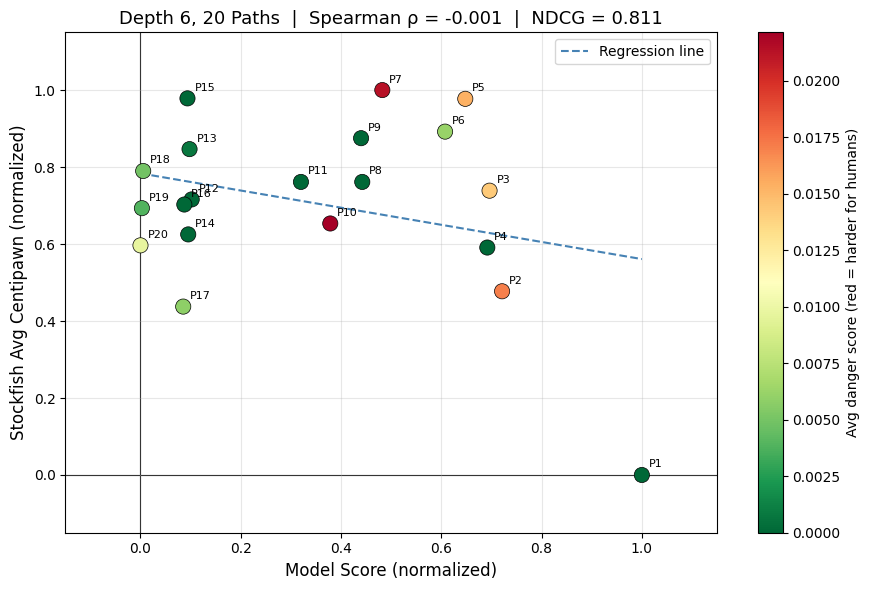

Spearman ρ = -0.001  (p=0.9975)
NDCG       = 0.811


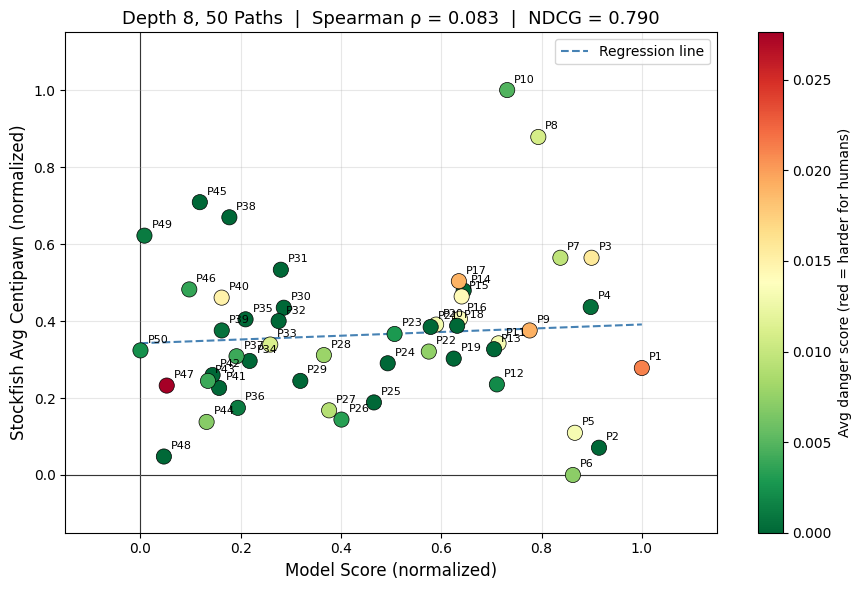

Spearman ρ = 0.083  (p=0.5660)
NDCG       = 0.790


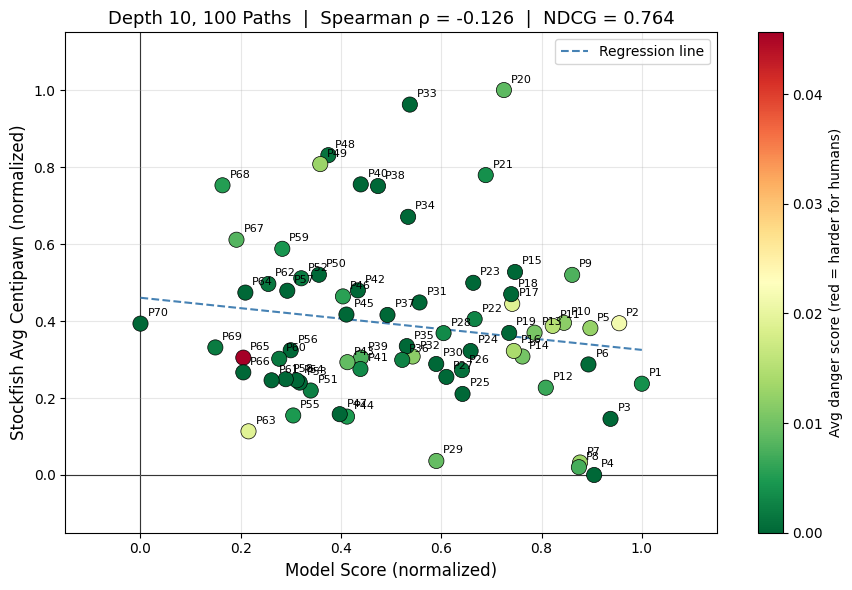

Spearman ρ = -0.126  (p=0.3002)
NDCG       = 0.764


In [ ]:
plot_scatter_comp(top_paths_stockfish_s, path_sf_scores_s, label="Depth 6, 20 Paths")
plot_scatter_comp(top_paths_stockfish_m, path_sf_scores_m, label="Depth 8, 50 Paths")
plot_scatter_comp(top_paths_stockfish_depth_10, path_sf_scores_depth_10, label="Depth 10, 100 Paths")

In [ ]:
get_top_weighted_paths()